In [116]:
from typing import *
from pathlib import Path
import gc

import itertools
import warnings
import numpy as np
import scipy
import torch
from torch import Tensor, nn
import pandas as pd
import json
from tqdm import tqdm

from Bio import SeqIO

import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels

from common.ml import ASVPreembeddedDataset, MicrobiomeSample
from gem.ml import safe_kl_div_loss, SGBAbundanceLayeredPredictionModel, SGBEmbedPoolConcatPredictionModel, SGBAbundancePredictionModel

# Baseline methods

In [2]:
class BaselinePredictor:
    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        raise NotImplementedError()

    def predict_batch_abundances(self, batched_inputs: List[List[str]]) -> np.ndarray:
        max_asvs = max(len(asv_list) for asv_list in batched_inputs)
        return np.stack([
            self.add_padding_1d(self.predict_abundances(batch), max_asvs)
            for batch in batched_inputs
        ], axis=0)

    @staticmethod
    def add_padding_1d(pred_vector: np.ndarray, max_size: int) -> np.ndarray:
        if max_size > len(pred_vector):
            pred_vector = np.concatenate([pred_vector, np.zeros(max_size - len(pred_vector), dtype=pred_vector.dtype)])
        return pred_vector

## Uniform abundance predictor

In [3]:
""" Class definition. """
class UniformAbundancePredictor(BaselinePredictor):
    def __init__(self):
        pass

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        pred = np.ones(len(asv_ids), dtype=float)
        pred = pred / np.sum(pred)
        return pred

## Nearest-Neighbor regression

In [130]:
def hamming_distance(seq1: str, seq2: str) -> int:
    assert len(seq1) == len(seq2), "For Hamming distance, sequences must be of equal length after alignment."
    distance = sum(1 for x, y in zip(seq1, seq2) if x != y)
    return distance


class ASVDistanceMatrix:
    def __init__(self, id_ordering: List[str], matrix: np.ndarray):
        self.id_ordering = id_ordering
        self.asv_to_idx = {asv_id: i for i, asv_id in enumerate(self.id_ordering)}
        self.matrix = matrix

    def entry(self, asv_i: str, asv_j: str) -> int:
        return self.matrix[self.asv_to_idx[asv_i], self.asv_to_idx[asv_j]]

    def nearest_neighbor(self, query: str, database: Set[str], neighbor_rank: int = 0) -> str:
        """
        Assuming query and database are all in self.id_ordering, return the nearest neighbor to the query.
        """
        assert neighbor_rank < len(database), "Can't request a neighbor rank of '{neighbor_rank}' when the database is of size {len(database)}!"
        if query in database:
            return query  # guaranteed distance of zero.

        database = list(database)
        database_indices = [self.asv_to_idx[asv] for asv in database]
        query_row = self.matrix[self.asv_to_idx[query], :]
        query_row = query_row[database_indices]

        best_idx = np.argsort(query_row)[neighbor_rank]
        return database[best_idx]

    @staticmethod
    def from_alignment(aln_fasta: Path) -> 'ASVDistanceMatrix':
        # Parse multiple alignment output.
        print(f"Loading alignments from {aln_fasta}")
        aligned_sequences = {}
        with open(aln_fasta, 'r') as handle:
            for record in SeqIO.parse(handle, "fasta"):
                aligned_sequences[record.id] = str(record.seq).upper()
        id_ordering = sorted(aligned_sequences.keys())

        # Fill in the matrix
        N = len(id_ordering)
        matrix = np.zeros(shape=(N, N), dtype=int)
        print(f"Populating {N} x {N} distance matrix...")
        for (i, asv_i), (j, asv_j) in tqdm(itertools.combinations(enumerate(id_ordering), r=2), total=N*(N-1) // 2):
            _d = hamming_distance(aligned_sequences[asv_i], aligned_sequences[asv_j])
            matrix[i, j] = _d
            matrix[j, i] = _d
        print("Done.")
        return ASVDistanceMatrix(id_ordering, matrix)

    def save(self, path: Path):
        np.savez(path, ids=np.array(self.id_ordering, dtype=object), matrix=self.matrix)

    @staticmethod
    def load(path: Path) -> 'ASVDistanceMatrix':
        print(f"Loading matrix from file {path}")
        data = np.load(path, allow_pickle=True)
        id_ordering = list(data['ids'])
        matrix = data['matrix']
        return ASVDistanceMatrix(id_ordering, matrix)


def create_distance_matrix(alignment_file: Path, save_dir: Path) -> ASVDistanceMatrix:
    matrix_file = save_dir / "distance_matrix.npz"
    if matrix_file.exists():
        asv_distance_matrix = ASVDistanceMatrix.load(matrix_file)
    else:
        asv_distance_matrix = ASVDistanceMatrix.from_alignment(alignment_file)
        asv_distance_matrix.save(matrix_file)
    return asv_distance_matrix


def geometric_mean(x: np.ndarray, eps: float = 1e-6) -> float:
    return np.exp(np.mean(np.log(x + eps)))

In [131]:
""" Class definition. """
class NearestNeighborAveragingPredictor(BaselinePredictor):
    """
    Predict an abundance by assigning a weight to each SGB in the specified query sample.
    The weight of SGB "X" is equal to the geometric mean of the abundance of NearestNeighbor(X) in the training samples.

    This class caches the result of input queries.

    Note: If "X" itself is in the training sample, then NearestNeighbor(X) = X, so we are counting the abundnaces of "X" itself in the training set.
    """
    def __init__(
            self,
            distance_matrix: ASVDistanceMatrix,
            train_dset: ASVPreembeddedDataset,
            k_num_neighbors: Optional[int] = None,
    ):
        assert len(train_dset) > 0
        self.train_dset = train_dset
        print("Initializing Nearest Neighbor predictor on {} training samples.".format(len(train_dset)))
        self.training_asvs = set()
        for sample in self.train_dset.sample_list:
            asv_ids, _, asv_abunds = self.train_dset.sample_converter.convert(sample)
            self.training_asvs = self.training_asvs.union(asv_ids)
        
        print("# Training ASVS: {}".format(len(self.training_asvs)))
        self.distance_matrix = distance_matrix
        self.k_num_neighbors = k_num_neighbors

        self._weight_cache = dict()  # for faster lookups. Assumes training samples don't change.

    def get_asv_weight(self, asv_id: str, neighbor_asv_id: str, sample_list: List[MicrobiomeSample]) -> float:
        """
        Compute the average relative abundance of the specified ASV's nearest neighbors in the training set.
        It is possible that the nearest-neighbor distance is zero; e.g. if the same ASV sequence showed up in the training set (either with the same ASV id or a different one, doesn't matter.)
        """
        if asv_id in self._weight_cache:
            return self._weight_cache[asv_id]
            
        weight_history = []
        # nearest_neighbor_asv_id = self.distance_matrix.nearest_neighbor(query=asv_id, database=self.training_asvs)
        for sample in sample_list:
            asv_ids, _, asv_abunds = self.train_dset.sample_converter.convert(sample)
            sample_dict = {_aid: _abund for _aid, _abund in zip(asv_ids, asv_abunds)}
            
            if neighbor_asv_id in sample_dict:
                weight_history.append(sample_dict[neighbor_asv_id])
            else:
                continue

        if len(weight_history) == 0:
            # if neighbor_asv_id is not present in the k-nearest-neighbor sample collection, simply take the average over all samples.
            if len(sample_list) < len(self.train_dset.sample_list):
                return self.get_asv_weight(asv_id, neighbor_asv_id, self.train_dset.sample_list)
            else:
                # neighbor_asv_id is not present in ANY of the training samples.
                # This is an unexpected error, since the neighbor_asv_id should always be in the training set.
                raise ValueError(f"[WARNING] In training data, found 0 occurrences of ASV's nearest neighbor. This should not happen!")
        weight = geometric_mean(np.array(weight_history, dtype=float))
        self._weight_cache[asv_id] = weight
        return weight

    def overlap_similarity(self, query_asv_list: List, other_sample: MicrobiomeSample) -> float:
        """
        Implements the Jaccard simliarity between two samples.
        :param query_asv_list: The list of ASV ids, but it is assumed that these IDs are all in the training set.
        :param other_sample:
        :return:
        """
        other_asv_list, _, _ = self.train_dset.sample_converter.convert(other_sample)
        for query_asv in query_asv_list:
            assert query_asv in self.training_asvs, f"Query ASV {query_asv} is not in training set! It is assumed that nearest-neighbor lookup has already been done."
        query_asv_set = set(query_asv_list)
        other_asv_set = set(other_asv_list)
        return len(query_asv_set.intersection(other_asv_set)) / len(query_asv_set.union(other_asv_set))

    def predict_weights(self, asv_ids: List[str])  -> np.ndarray:
        """
        Make the prediction based on training data.
        """
        """ Calculate prediction. """
        neighbor_asvs = {
            asv_id: self.distance_matrix.nearest_neighbor(asv_id, database=self.training_asvs)
            for asv_id in asv_ids
        }

        # k-nn approach: identify the closest k samples.
        if self.k_num_neighbors is not None:
            # decreasing order of similarity (reverse=True)
            sample_subset = sorted(
                self.train_dset.sample_list,
                key=lambda other_sample: self.overlap_similarity(
                    [neighbor_asvs[query_asv_id] for query_asv_id in asv_ids],
                    other_sample
                ),
                reverse=True
            )
            sample_subset = sample_subset[:self.k_num_neighbors]
        else:
            sample_subset = self.train_dset.sample_list

        asv_weights = np.array(
            [
                self.get_asv_weight(asv_id, neighbor_asvs[asv_id], sample_subset) for asv_id in asv_ids
            ],
            dtype=float
        )
        return asv_weights

    def predict_abundances(self, asv_ids: List[str]) -> np.ndarray:
        """ Compute output. """
        wts = self.predict_weights(asv_ids)
        
        # normalize and add padding.
        if np.sum(wts) == 0:
            raise ValueError("Unable to make any reasonable prediction! This should not occur.")
        pred = wts / np.sum(wts)
        return pred

# Model evaluation code

In [122]:
# additional metrics
def bray_curtis(x: np.ndarray, y: np.ndarray):
    """
    Assume x, y are vectors which are identically indexed according to species (1, ..., n).
    Computes the Bray-curtis distance:
    BC = 1 - 2 * SUM_i[ min(x_i, y_i) ] / SUM_i [ x_i + y_i ]
    """
    numer = np.minimum(x, y).sum()
    denom = x.sum() + y.sum()
    return 1 - 2 * (numer / denom)


def evaluate_method(
    inference_fn: Callable[[ASVPreembeddedDataset, int], Tensor],
    dset: ASVPreembeddedDataset
) -> pd.DataFrame:
    """
    Function which evaluates the function (precisely how the evaluation is done, including pre & post-processing, is given by inference_fn) and outputs a DataFrame tabulating the results.

    :param inference_fn: A function (e.g. lambda expression) which takes a MicrobiomeSample as input and outputs a (abund_predictions) tensor. The abund_predictions should be a vector of LOGS of relative abundances.
    :param dset: The dataset to test on.
    """
    df_entries = []

    n_samples = len(dset)
    for sample_idx in tqdm(range(n_samples)):
        """ Prediction. """
        try:
            pred_asv_log_abunds: Tensor = inference_fn(dset, sample_idx)
        except Exception as e:
            print(f"During inference of sample {sample_idx}, got an error.")
            print(f"The error was: {e}")
            raise
        assert len(pred_asv_log_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert torch.logsumexp(pred_asv_log_abunds, dim=0).isclose(torch.tensor(0.0), rtol=1e-3, atol=1e-4).item(), f"Expected logsumexp(pred) to be equal to 0.0, got {torch.logsumexp(pred_asv_log_abunds, dim=0).item()}."
        # assert num_sgbs == pred_sgb_log_abunds.shape[0], "Pred abundances should have the same size/shape as the list of true SGB ids."

        """ Ground-truth. """
        _, true_asv_abunds = dset.true_abundance_profile(sample_idx)
        assert len(true_asv_abunds.shape) == 1, "Expected a 1-d tensor for the true abundances."
        assert true_asv_abunds.sum().isclose(torch.tensor(1.0), rtol=1e-4, atol=1e-7).item(), f"Expected true relative abundances to sum to 1.0, got {true_asv_abunds.sum()}"
        # assert num_sgbs == true_sgb_abunds.shape[0], "True abundances should have the same size/shape as the list of true SGB ids."

        # # DEBUG
        # print("Sample idx: ", sample_idx)
        # for pred, truth in zip(torch.exp(pred_sgb_log_abunds), true_sgb_abunds):
        #     print(f"pred: {pred}, truth: {truth}")
        # raise Exception("DEBUG")

        """ Metric evaluation. """
        # KL Divergence
        kl_loss = safe_kl_div_loss(
            pred_asv_log_abunds.unsqueeze(0),
            torch.log(true_asv_abunds.unsqueeze(0)),
        ).item()

        # Root-Mean-Square-Log error
        log_10_conversion = np.log10(np.e)
        rmsle_loss = torch.sqrt(torch.mean(torch.square(
            log_10_conversion * (pred_asv_log_abunds - torch.log(true_asv_abunds))
        ))).item()

        # Spearman rank correlation
        spearman = scipy.stats.spearmanr(
            torch.log(true_asv_abunds).numpy(),
            pred_asv_log_abunds.numpy()
        )

        # Bray-curtis
        bc = bray_curtis(true_asv_abunds.numpy(), torch.exp(pred_asv_log_abunds).numpy())

        df_entries.append({
            'SampleIdx': sample_idx,
            'KL_err': kl_loss,
            'RMSL_err': rmsle_loss,
            'SpearmanCorr': spearman.statistic,
            'BrayCurtis': bc,
            'NumSGB': len(true_asv_abunds),
        })
    return pd.DataFrame(df_entries)

## Baseline models

In [6]:
def evaluate_baseline_model(
    baseline_method: BaselinePredictor,
    dset_object: ASVPreembeddedDataset,
) -> pd.DataFrame:
    """
    A wrapper for evaluate_method for baseline methods.

    This creates a function that implements the inference_fn for evaluate_method, and invokes it to return a table.
    :param baseline_method:
    :param dset_object:
    :return: dataframe of results.
    """
    def predict_fn(_dset: ASVPreembeddedDataset, _idx: int):
        asv_ids, _  = _dset.true_abundance_profile(_idx)
        # subset_df = dset_df.loc[dset_df.index == sample_id]
        # assert subset_df.shape[0] == 1, f"Expected 1 sample matching ID {sample_id}, got: {subset_df.shape[0]}"
        # extractor = MetaphlanProfileParser(subset_df)
        # target_sample = next(iter(extractor.samples()))

        # Note: the below code ensures that we only include SGBs that are present in the PhyloPhlAn marker DB.
        abunds = baseline_method.predict_abundances(asv_ids)
        abunds = torch.from_numpy(abunds + 1e-8).to(torch.float32)  # add padding so that spurious "zeroes" don't result in NaNs or infs.
        abunds = abunds / abunds.sum()   # renormalize.
        return torch.log(abunds)

    return evaluate_method(predict_fn, dset_object)

## torch models

In [88]:
def perform_inference_torch_model(
        torch_model: nn.Module,
        dset: ASVPreembeddedDataset,
        sample_idx: int,
        eval_device: torch.device = torch.device('cuda')
) -> Tensor:
    """
    :param torch_model: A pytorch model which takes as input a batched tensor of SGB embeddings, which was trained using the function 'main_training_loop'. This model should output logits.
    """
    _, features, _ = dset[sample_idx]
    n_taxa = len(features)
    features = features.unsqueeze(0).unsqueeze(2).to(eval_device)
    gene_padding_mask = torch.ones((1, n_taxa, 1), dtype=torch.bool).to(eval_device)
    taxa_padding_mask = torch.ones((1, n_taxa), dtype=torch.bool).to(eval_device)

    torch_model.eval()
    with torch.no_grad():
        nn_output = torch_model(features, gene_padding_mask, taxa_padding_mask).to("cpu").to(torch.float32)
        nn_output = nn_output[0]
        n_finite_nn = (~torch.isinf(nn_output)).sum().item()
        n_finite_expected = n_taxa
        assert n_finite_expected == n_finite_nn, f"Expected {n_finite_expected} entries of model output to all be finite, got: {n_finite_nn}"

        gc.collect()
        torch.cuda.empty_cache()
        log_prob_output = nn.functional.log_softmax(nn_output, dim=-1)    # log probabilities
    return log_prob_output


def load_torch_model(
    model_savedir: Path, device: torch.device,
    plot_loss_history: bool = False
) -> nn.Module:
    model_config_file = model_savedir / "model_config.json"
    metadata_file = model_savedir / "metadata.txt"
    assert model_config_file.exists(), f"Pytorch model config '{model_config_file}' does not exist!"
    assert metadata_file.exists(), f"Pytorch model training metadata '{metadata_file}' does not exist!"

    with open(metadata_file, "rt") as f:
        metadata = dict()
        for line_idx, line in enumerate(f):
            line = line.strip()
            tokens = line.split("=")
            assert len(tokens) == 2, f"Unparseable metadata, line {line_idx+1}: {line}"
            k, v = tokens
            metadata[k] = v
    assert "epochs" in metadata, f"Entry 'epochs' was not found in metadata ({metadata_file})"
    n_epochs = int(metadata["epochs"])

    checkpoint_files = {}
    for pt_file in (model_savedir / 'model_checkpoints').glob("checkpoint_*.pt"):
        checkpoint_number = int(pt_file.stem.split("_")[-1])
        checkpoint_files[checkpoint_number] = pt_file
    if len(checkpoint_files) == 0:
        raise ValueError(f"No saved checkpoint model states in {model_savedir}")

    # try to load the latest state.
    checkpoint_epochs = sorted(checkpoint_files.keys())
    last_checkpoint_epoch = checkpoint_epochs[-1]
    checkpoint_fpath = checkpoint_files[last_checkpoint_epoch]
    if last_checkpoint_epoch < n_epochs:
        print(f"Last trained epoch was {checkpoint_epochs[-1]}; loading last-known state file {checkpoint_fpath}")
    elif last_checkpoint_epoch > n_epochs:
        raise ValueError(f"Last trained epoch checkpoint {last_checkpoint_epoch} exceeds metadata epochs {n_epochs}. Dir: {model_savedir}")
    else:
        pass

    with open(model_config_file, "rt") as json_cfg:
        model_cfg = json.load(json_cfg)
        model_class_name = model_cfg['class']
        del model_cfg['class']  # unnecessary for evaluation.
        del model_cfg['init_rng_seed']  # unnecessary for evaluation.

    if model_class_name == "SGBAbundanceLayeredPredictionModel":
        model = SGBAbundanceLayeredPredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBAbundancePredictionModel":
        model = SGBAbundancePredictionModel(**model_cfg).to(device)
    elif model_class_name == "SGBEmbedPoolConcatPredictionModel":
        model = SGBEmbedPoolConcatPredictionModel(**model_cfg).to(device)
    else:
        raise KeyError("Unsupported model class name: {}".format(model_class_name))

    model = torch.compile(model)
    checkpoint: Dict[str, Any] = torch.load(checkpoint_fpath)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    if plot_loss_history:
        epoch_history: List[int] = checkpoint['epoch_history']
        training_history: List[float] = checkpoint['training_history']
        test_history: List[float] = checkpoint['test_history']
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.plot(epoch_history, training_history, color='red', label='Training Loss')
        ax.plot(epoch_history, test_history, color='green', label='Test Loss')
        ax.set_ylabel("Loss")
        ax.set_xlabel("Epoch")
        ax.legend()
        plt.show()
        plt.close(fig)
    return model


def evaluate_torch_model(
    model_savedir: Path,
    dset: ASVPreembeddedDataset,
    device: torch.device = torch.device('cuda'),
    plot_loss_history: bool = False
) -> pd.DataFrame:
    """
    A wrapper around the previously-defined 'evaluate_method' function.

    This function was written so that we can load the model just once from a previously-saved pytorch model state file.
    """
    model = load_torch_model(model_savedir, device, plot_loss_history=plot_loss_history)
    return evaluate_method(
        lambda _dset, _idx: perform_inference_torch_model(model, _dset, _idx, eval_device=device),
        dset
    )

# Evaluation & Benchmark

In [133]:
torch.set_float32_matmul_precision('high')

embed_models = ['dnabert-s', 'evo-1-8k-base_hyena5', 'evo2_7b_hyena10']
pred_models = ['epc_pool_kl', 'epc_nopool_kl']
# embed_models = ['dnabert-s']
# pred_models = ['epc_pool_kl']
baseline_methods = ['uniform', 'asv_nearest_neighbor']

abundance_table_dir = Path("/data/cctm/youn/human_microbiome_compendium/asv")

In [126]:
def evaluate_all(dset_name: str, results_dir: Path):
    results_dir.mkdir(exist_ok=True, parents=True)
    dset_dir = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / dset_name
    embeddings_dir = dset_dir / "embeddings"

    assert dset_dir.exists(), f"Dataset {dset_name} files not found! ({dset_dir})"
    assert embeddings_dir.exists(), f"Embeddings root dir for {dset_name} not found! ({embeddings_dir})"

    train_df = pd.read_csv(dset_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(dset_dir / "test.tsv", sep="\t")

    # torch methods
    test_dset_for_baseline = None
    train_dset_for_baseline = None
    torch_model_names = []
    for embed_model in embed_models:
        print(f"Embed model = {embed_model}")
        # train_dset = ASVPreembeddedDataset(train_df, abundance_table_dir, embedding_h5_path)
        embedding_h5_path = embeddings_dir / f'{embed_model}.h5'
        test_dset = ASVPreembeddedDataset(test_df, abundance_table_dir, embedding_h5_path)
        if test_dset_for_baseline is None:
            test_dset_for_baseline = test_dset
            train_dset_for_baseline = ASVPreembeddedDataset(train_df, abundance_table_dir, embedding_h5_path)

        for pred_model in pred_models:
            print(f"\tPred model = {pred_model}")
            model_savedir = dset_dir / "trained_models" / embed_model / pred_model
            print("Model savedir:", model_savedir)
            evaluate_torch_model(
                model_savedir=model_savedir,
                dset=test_dset,
                device=torch.device('cuda'),
                plot_loss_history=False
            ).to_csv(results_dir / f"{embed_model}__{pred_model}.tsv", sep='\t', index=False)

    # Initialize baseline methods.
    # create_distance_matrix(alignment_file: Path, save_dir: Path)
    alignment_file = dset_dir / "asv_16s_processing" / "asv_alignment.fasta"
    distance_matrix = create_distance_matrix(alignment_file, alignment_file.parent)
    baseline_method_objs = {
        'uniform': UniformAbundancePredictor(),
        'asv_nearest_neighbor': NearestNeighborAveragingPredictor(distance_matrix, train_dset_for_baseline)
    }
    for baseline_name in baseline_methods:
        if baseline_name not in baseline_method_objs:
            raise KeyError("Baseline method `{baseline_name}` not defined!")

    # baseline methods eval
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for baseline_name, baseline_method in baseline_method_objs.items():
            print("Baseline method:", baseline_name)
            evaluate_baseline_model(
                baseline_method=baseline_method,
                dset_object=test_dset_for_baseline,
            ).to_csv(results_dir / f'{baseline_name}.tsv', sep='\t', index=False)

In [132]:
dset_name = "american_gut_USCA"
evaluate_all(dset_name, results_dir=Path("results") / dset_name)

Embed model = dnabert-s
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 6593 embeddings in memory.
Loading tensor embeddings from /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/embeddings/dnabert-s.h5. Embedding shape = (768,))
Caching embeddings in memory...
Cached 6593 embeddings in memory.
	Pred model = epc_pool_kl
Model savedir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/trained_models/dnabert-s/epc_pool_kl
Loading matrix from file /data/bwh-comppath-seq/youn/human_microbiome_compendium/american_gut_USCA/asv_16s_processing/distance_matrix.npz
Initializing Nearest Neighbor predictor on 1189 training samples.
# Training ASVS: 6318
Baseline method: uniform


100%|███████████████████████████| 118/118 [00:00<00:00, 6045.66it/s]


Baseline method: asv_nearest_neighbor


100%|█████████████████████████████| 118/118 [03:51<00:00,  1.97s/it]


# Plotting

## plotting fn

In [91]:
from scipy.stats import wilcoxon

def boxplot_with_paired_significance(data, hue, y, sample_col, annot_pvals: bool = False, ax=None, hue_order=None, palette=None, correction='fdr_bh'):
    """
    Draws a seaborn boxplot and annotates pairwise *paired* statistical significance between hue groups, matching by 'Sample' column.
    Uses paired Wilcoxon test with multiple hypothesis correction.
    
    Parameters:
    -----------
    correction : str, default 'holm'
        Method for multiple hypothesis correction. Options: 'bonferroni', 'holm', 'fdr_bh', 'fdr_by'
    """
    import statsmodels.stats.multitest as smt
    
    if hue_order is None:
        hue_order = sorted(data[hue].unique())
    group_locs = {level: i for i, level in enumerate(hue_order)}
    
    # Draw the box plot: only x=hue, y=value
    sb.boxplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, legend=False, showfliers=False)
    sb.stripplot(x=hue, y=y, hue=hue, data=data, ax=ax, order=hue_order, hue_order=hue_order, palette=palette, dodge=False, alpha=0.5, edgecolor='black', linewidth=1.0)
    ax.set_xticklabels(hue_order, rotation=90)

    if annot_pvals:
        # Get y-axis range for proper scaling
        ylim = ax.get_ylim()
        y_range = ylim[1] - ylim[0]
        y_max = data[y].max()
        
        # Starting position for annotations (4% above data max)
        y_start = y_max + y_range * 0.04
        
        # Pairwise significance testing
        pairs = list(itertools.combinations(hue_order, 2))
        p_values = []
        test_results = []
        
        # Collect all p-values first
        for h1, h2 in pairs:
            d1 = data[data[hue] == h1][[sample_col, y]]
            d2 = data[data[hue] == h2][[sample_col, y]]
            joined = d1.merge(d2, on=sample_col, suffixes=('_1', '_2'))
            v1 = joined[y + '_1']
            v2 = joined[y + '_2']
            stat, p = wilcoxon(v1, v2, zero_method='wilcox', correction=False)
            p_values.append(p)
            test_results.append((h1, h2, stat, p))
        
        # Apply multiple hypothesis correction
        if len(p_values) > 1:
            rejected, p_corrected, _, _ = smt.multipletests(p_values, method=correction)
        else:
            rejected = [p_values[0] < 0.05] if p_values else []
            p_corrected = p_values
        
        # Annotation with corrected p-values
        annotation_idx = 0  # Counter for positioning annotations
        for idx, (h1, h2, stat, p_raw) in enumerate(test_results):
            p_adj = p_corrected[idx]
            
            stars = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'n.s.'
            
            x1, x2 = group_locs[h1], group_locs[h2]
            
            # Calculate bracket position and height based on y-axis range
            y_bar = y_start + annotation_idx * y_range * 0.15  # 15% spacing between brackets
            bracket_height = y_range * 0.02  # 2% of y-range for bracket height
            text_offset = y_range * 0.001  # offset for text above bracket
            
            # Draw significance bracket
            ax.plot([x1, x1, x2, x2], 
                    [y_bar, y_bar + bracket_height, y_bar + bracket_height, y_bar], 
                    lw=1.2, c='k')
            
            # Add significance text with adjusted p-value info
            text = f"{stars}"
            ax.text((x1 + x2) / 2, y_bar + bracket_height + text_offset, 
                    text, ha='center', va='bottom', color='k', fontsize=11)
            
            annotation_idx += 1
        
        # Add correction method info to plot
        ax.text(0.02, 0.98, f'Multiple comparisons: {correction}', 
                transform=ax.transAxes, verticalalignment='top', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))
    else:
        print("Skipping p-value annotation.")
    
    plt.tight_layout()
    return ax

## execute the plotting code.

In [134]:
def draw_plot_for_dataset(results_dir: Path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    # axes = axes.flatten()
    pytorch_palette = sb.color_palette("Paired", n_colors=8)
    baseline_palette = sb.color_palette('Greys', n_colors=2)
    
    
    eval_result_dfs = []
    palette = {}
    method_order = []
    
    # baseline methods
    method_idx_for_color = 0
    for baseline_name in baseline_methods:
        method_name = baseline_name
        method_order.append(method_name)
        eval_result_dfs.append(
            pd.read_csv(results_dir / f"{baseline_name}.tsv", sep='\t').assign(
                Method=method_name
            )
        )
        palette[method_name] = baseline_palette[method_idx_for_color]
        method_idx_for_color += 1
    
    # torch models
    method_idx_for_color = 0
    for embed_model, pred_model in itertools.product(embed_models, pred_models):
        method_name = f'{embed_model}__{pred_model}'
        method_order.append(method_name)
        eval_result_dfs.append(
            pd.read_csv(results_dir / f"{embed_model}__{pred_model}.tsv", sep='\t').assign(
                Method=method_name
            )
        )
        palette[method_name] = pytorch_palette[method_idx_for_color]
        method_idx_for_color += 1
    
    
    eval_result_df = pd.concat(eval_result_dfs, ignore_index=True)
    del eval_result_dfs
    boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='KL_err', sample_col='Sample', ax=axes[0], palette=palette, hue_order=method_order, annot_pvals=False)
    boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='RMSL_err', sample_col='Sample', ax=axes[1], palette=palette, hue_order=method_order, annot_pvals=False)
    boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='BrayCurtis', sample_col='Sample', ax=axes[2], palette=palette, hue_order=method_order, annot_pvals=False)
    # boxplot_with_paired_significance(eval_result_df.loc[eval_result_df['Method'].isin(method_order)], hue='Method', y='SpearmanCorr', sample_col='Sample', ax=axes[2], palette=palette, hue_order=method_order, annot_pvals=False)
    
    plt.savefig(results_dir / "benchmark.png", bbox_inches='tight')

/tmp/ipykernel_505401/40879153.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=90)
/tmp/ipykernel_505401/40879153.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=90)
/tmp/ipykernel_505401/40879153.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hue_order, rotation=90)


Skipping p-value annotation.
Skipping p-value annotation.
Skipping p-value annotation.


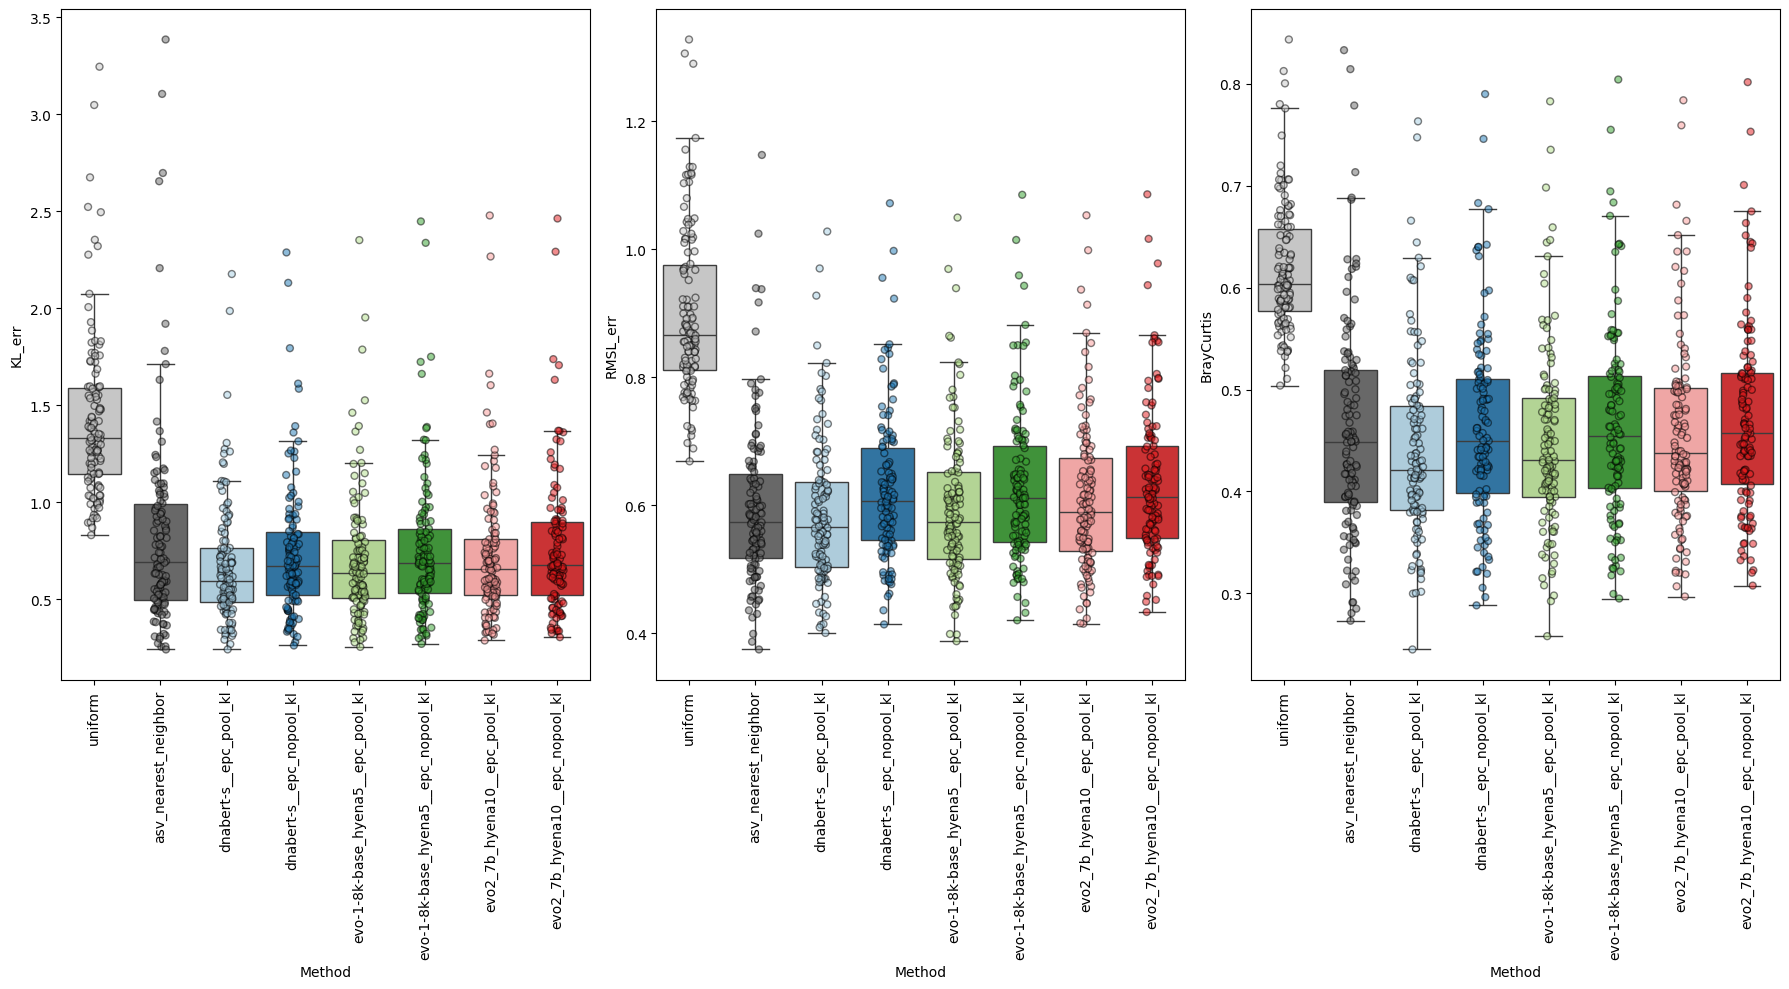

In [135]:
draw_plot_for_dataset(Path("results") / "american_gut_USCA")